In [26]:
#Importamos las librerias que vamos a usar
import pandas as pd

In [27]:
# Cargamos los datos
data_ecommerce_original = pd.read_csv('files_folder/ecommerce_raw_2024.csv')
print(data_ecommerce_original.head())

# Creamos una copia
data_ecommerce =data_ecommerce_original.copy()

    order_id  customer_id           order_date   country category_name  \
0  ORD-00001         2063  2024-01-01 00:05:00  Colombia          toys   
1  ORD-00002         2348  2024-01-01 00:15:00    Mexico          toys   
2  ORD-00003         1900  2024-01-01 00:37:00  Colombia          Toys   
3  ORD-00004         1530  2024-01-01 01:04:00  Colombia          Toys   
4  ORD-00005         1115  2024-01-01 01:08:00     Chile      Clothing   

   price_usd  delivery_days  
0      73.75            3.0  
1      21.18            5.0  
2     175.87            NaN  
3     185.72            3.0  
4       2.23            7.0  


# Auditoría y Limpieza de Datos (Data Quality)

In [28]:
# Verificamos cuantas minusculas hay la columna 'category_name'
conteo_lower = data_ecommerce['category_name'].str.islower().sum()
print("Cuantas minusculas hay")
print(f'Datos con texto minuscula: {conteo_lower}')

Cuantas minusculas hay
Datos con texto minuscula: 6713


In [29]:
# Limpieza de texto anomalo como quitar espacios extras, capitalizar primera letra
# Comenzamos con la columna 'category_name', ya que es donde se nota más este error
data_ecommerce['category_name'] = data_ecommerce['category_name'].str.strip().str.capitalize()
print(data_ecommerce.head())

    order_id  customer_id           order_date   country category_name  \
0  ORD-00001         2063  2024-01-01 00:05:00  Colombia          Toys   
1  ORD-00002         2348  2024-01-01 00:15:00    Mexico          Toys   
2  ORD-00003         1900  2024-01-01 00:37:00  Colombia          Toys   
3  ORD-00004         1530  2024-01-01 01:04:00  Colombia          Toys   
4  ORD-00005         1115  2024-01-01 01:08:00     Chile      Clothing   

   price_usd  delivery_days  
0      73.75            3.0  
1      21.18            5.0  
2     175.87            NaN  
3     185.72            3.0  
4       2.23            7.0  


In [30]:
# Verificamos que no hayan quedado ningun dato con minusculas
conteo_lower = data_ecommerce['category_name'].str.islower().sum()
print("Cuantas minusculas hay")
print(f'Datos con texto minuscula: {conteo_lower}')

Cuantas minusculas hay
Datos con texto minuscula: 0


In [31]:
# Se hace el filtrado para no perder datos escenciales
filtrado_mask = (data_ecommerce['price_usd'] > 0) & (data_ecommerce['price_usd'] < 10000)
filtrado_respuesta = data_ecommerce[filtrado_mask]
print(filtrado_respuesta)

#Con esta máscara vamos a trabajar, ya que no contiene valores menores a 50 y mayores a 10,000

        order_id  customer_id           order_date   country category_name  \
0      ORD-00001         2063  2024-01-01 00:05:00  Colombia          Toys   
1      ORD-00002         2348  2024-01-01 00:15:00    Mexico          Toys   
2      ORD-00003         1900  2024-01-01 00:37:00  Colombia          Toys   
3      ORD-00004         1530  2024-01-01 01:04:00  Colombia          Toys   
4      ORD-00005         1115  2024-01-01 01:08:00     Chile      Clothing   
...          ...          ...                  ...       ...           ...   
14995  ORD-14996         3013  2024-12-30 20:43:00    Mexico      Clothing   
14996  ORD-14997         4894  2024-12-30 20:58:00  Colombia      Clothing   
14997  ORD-14998         2020  2024-12-30 23:47:00     Spain          Toys   
14998  ORD-14999         1292  2024-12-30 23:49:00    Mexico          Toys   
14999  ORD-15000         4096  2024-12-30 23:58:00  Colombia   Electronics   

       price_usd  delivery_days  
0          73.75            3

# Salud Financiera (Tendencia y Crecimiento)

In [32]:
# Hacemos la verificación
# print(data_ecommerce['order_date'].dtypes) # resultado esperable: str

# Los datos dentro de la columna son 'order_date' estan tipo texto osea 'srt', pasaremos esto a tipo númerico
filtrado_respuesta['order_date'] =pd.to_datetime(filtrado_respuesta['order_date'])
# print(filtrado_respuesta['order_date'].dtypes) # resultado esperable : datetime64[us]


# Se importa la libreria locale para poner los nombres de los meses en español, ya que por defecto están en inglés
import locale

# Establecemos la configuración regional a español de España (puede variar según el sistema operativo)
locale.setlocale(locale.LC_TIME, 'Spanish_Spain')

# Hacemos el resampling por mes, sumando las filas y así tener solo 12 filas
ventas_mensuales_serie = filtrado_respuesta.resample(
    'ME', on='order_date' #resample por mes, con la columna 'order_date' como referencia
)['price_usd'].sum()    #sumamos los valores de 'price_usd' para cada mes

# Convertimos a DataFrame para agregar el cálculo MoM
ventas_mensuales = pd.DataFrame({
    'ingreso_mensual': ventas_mensuales_serie,
    'crecimiento_mom_%': (ventas_mensuales_serie.pct_change() * 100).round(2)
})

ventas_mensuales.index = ventas_mensuales.index.strftime('%B').str.capitalize() # Cambiamos el índice a los nombres de los meses en español, con la primera letra en mayúscula

print(ventas_mensuales)

            ingreso_mensual  crecimiento_mom_%
order_date                                    
Enero             190306.15                NaN
Febrero           177509.57              -6.72
Marzo             194109.36               9.35
Abril             181310.28              -6.59
Mayo              183528.90               1.22
Junio             179026.40              -2.45
Julio             211696.46              18.25
Agosto            183031.03             -13.54
Septiembre        177187.45              -3.19
Octubre           197390.09              11.40
Noviembre         186219.46              -5.66
Diciembre         196057.58               5.28


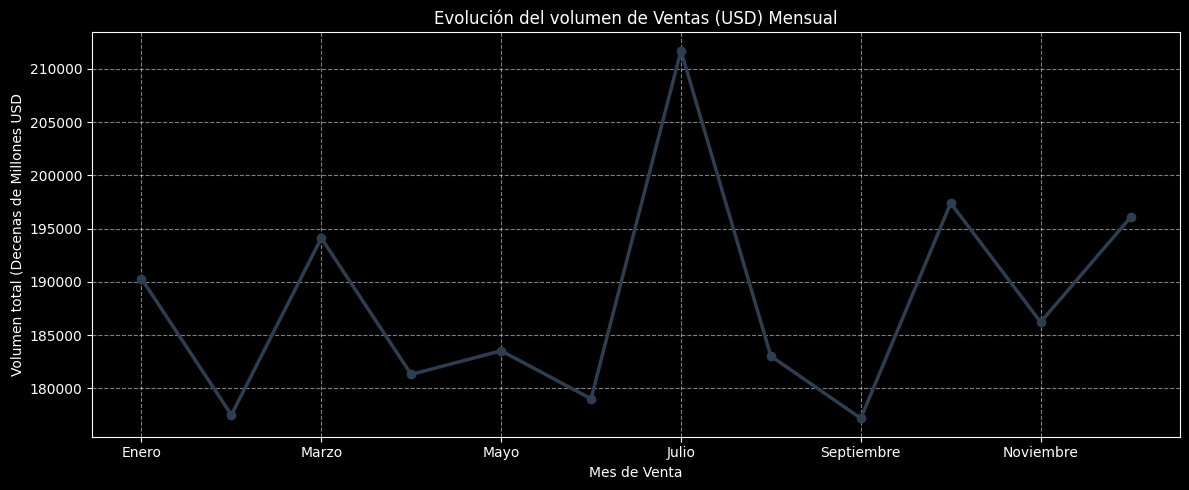

In [33]:
#Importamos la libreria de visualización
import matplotlib.pyplot as plt

# Graficamos la evolución de las ventas mensuales
ventas_mensuales['ingreso_mensual'].plot(
    kind='line',
    figsize=(12,5),
    color='#2c3e50',   # Azul oscuro corporatico
    linewidth=2.5,
    marker='o', # Circulos en cada mes para ver el dato exacto
    title='Evolución del volumen de Ventas (USD) Mensual'
)
plt.xlabel('Mes de Venta')
plt.ylabel('Volumen total (Decenas de Millones USD')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Inteligencia de Mercado (Geografía y Producto)

In [34]:
# Agrupamos el país por mayor número de ventas
ventas_por_pais = (
    filtrado_respuesta.groupby('country', as_index=False)['price_usd'] # Agrupamos por país, sin usar el país como índice
    .sum()
    .rename(columns={'price_usd': 'total_ventas_pais'}) # Renombramos la columna de ventas totales por país
    .sort_values(by='total_ventas_pais', ascending=False) # Ordenamos de mayor a menor por el total de ventas por país
)
print(ventas_por_pais[['country', 'total_ventas_pais']])

    country  total_ventas_pais
1  Colombia          684755.41
2    Mexico          562293.39
4       USA          437027.83
3     Spain          336943.46
0     Chile          236352.64


In [35]:
# Agrupamos por categoría de producto que más se vende
categoria_mas_vendida = (
    filtrado_respuesta.groupby('category_name')
    .size()  # contamos el número de filas para cada categoría, lo que nos da la cantidad vendida por categoría
    .reset_index(name='cantidad_vendida')  # reinicia el índice y nombra la nueva columna como 'cantidad_vendida'
    .sort_values(by='cantidad_vendida', ascending=False)  # ordena de mayor a menor
)
print(categoria_mas_vendida[['category_name', 'cantidad_vendida']])

   category_name  cantidad_vendida
1    Electronics              4881
0       Clothing              3392
4           Toys              3286
2           Home              1692
3  Home & garden              1689


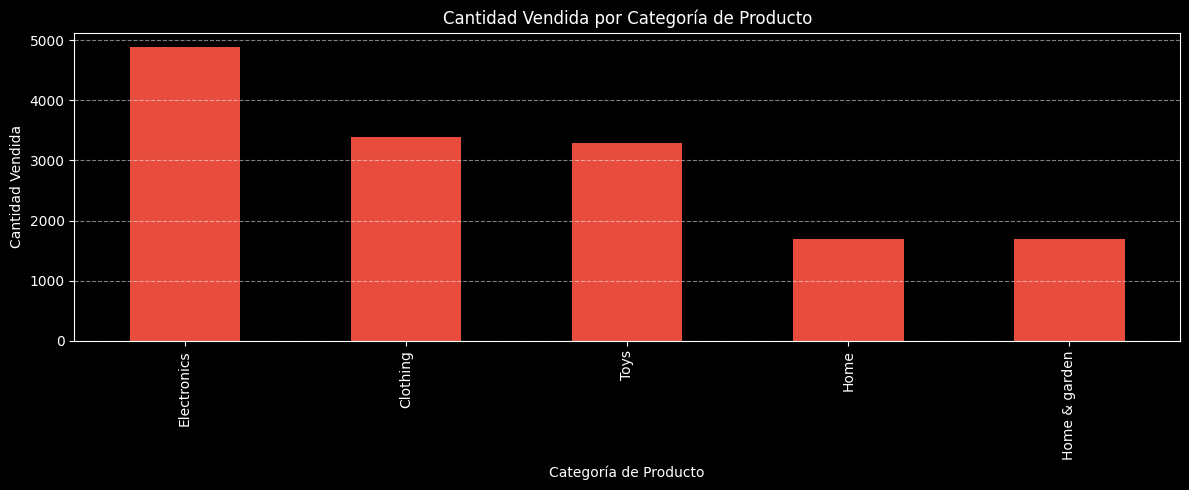

In [36]:
#Graficamos por grafico de barras la categoría de producto más vendida
categoria_mas_vendida.set_index('category_name')['cantidad_vendida'].plot(
    kind='bar',
    figsize=(12,5),
    color='#e74c3c',   # Rojo corporativo
    title='Cantidad Vendida por Categoría de Producto'
)

plt.xlabel("Categoría de Producto")
plt.ylabel("Cantidad Vendida")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Eficiencia Logística (El problema de los envíos)

In [37]:
# Agrupamos por país, para así ver el número de envios y su media para ver el tiempo promedio de envío por país
envios_por_pais = (
    filtrado_respuesta.groupby('country', as_index=False) # Agrupamos por país, sin usar el país como índice
    .agg(dias_promedio_entrega=('delivery_days', 'mean')) # Usamos .agg para calcular la media de los días de entrega por país, y renombramos esa columna como 'dias_promedio_entrega'
    .sort_values(by='dias_promedio_entrega', ascending=False)  # Ordenamos país con mayor tiempo promedio de envío a menor
)
print(envios_por_pais[['country', 'dias_promedio_entrega']])

    country  dias_promedio_entrega
1  Colombia               5.022574
4       USA               5.017749
3     Spain               4.999066
2    Mexico               4.994883
0     Chile               4.985734


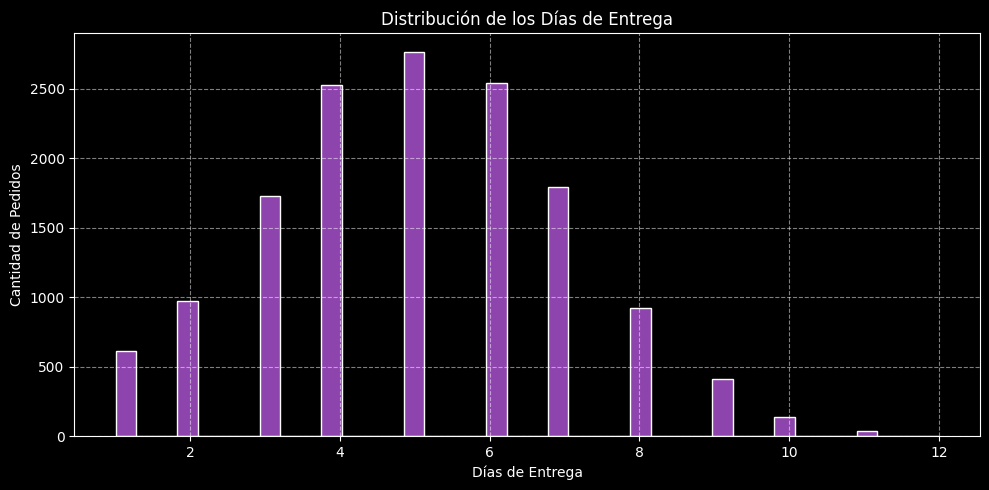

In [38]:
# Hacemos un histograma para visualizar la distribución de los días de entrega
filtrado_respuesta['delivery_days'].plot(
    kind='hist', # Tipo de gráfico: histograma para ver la distribución de los días de entrega
    bins=40, # Dividimos el rango de días de entrega en 40 "cajones" para una visualización detallada
    figsize=(10,5), # Tamaño del gráfico
    color='#8e44ad', # Morado corporativo
    edgecolor='white', # Borde blanco para separar visualmente los cajones del histograma
    title='Distribución de los Días de Entrega' # Título del gráfico
)
plt.xlabel('Días de Entrega') # Etiqueta del eje x
plt.ylabel('Cantidad de Pedidos') # Etiqueta del eje y
plt.grid(True, linestyle='--', alpha=0.5) # Agregamos una cuadrícula para facilitar la lectura del gráfico
plt.tight_layout() # Ajustamos el diseño para que no se solapen los elementos del gráfico
plt.show() # Mostramos el gráfico